In [14]:
!pwd

/home/kataoka/TC_stabilizer_test/figures/X-loop/X-loop_0-1


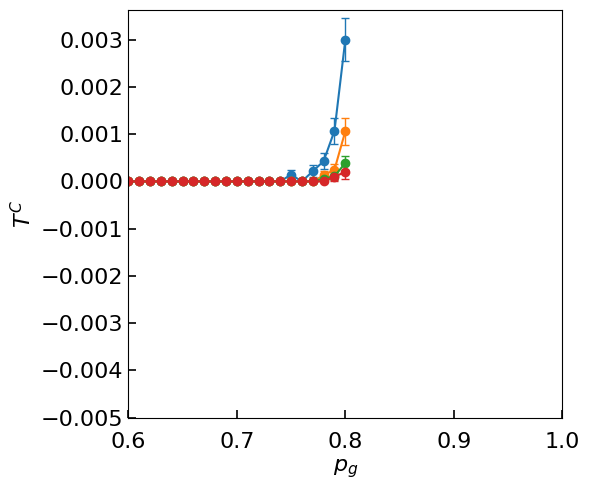

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'  # テキストをフォントのまま保持

# ファイルを取得
files = glob.glob("results_pz_0.0_Lx_*_Nd_*_NT_*.npz")

# (Lx, Nd, NT, filename) のタプルを作ってソート
file_info = []
for fname in files:
    match = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+).npz", fname)
    if match:
        Lx, Nd, NT = map(int, match.groups())
        file_info.append((Lx, Nd, NT, fname))
# Lx の昇順でソート
file_info.sort(key=lambda x: x[0])

# --- average 用の figure ---
fig_avg, ax_avg = plt.subplots(figsize=(6,5))

use_Lx = [14, 16, 18, 20, 22]

for Lx, Nd, NT, fname in file_info:
    if Lx not in use_Lx:
        continue  # 指定外の Lx はスキップ
    data = np.load(fname)
    pg = data["pg"]
    R2z_ave = data["R2z_loop_ave"]
    R2z_err = data["R2z_loop_err"]
    R2z_var = data["R2z_loop_var"]
    order = np.argsort(pg)
    pg = pg[order]
    R2z_ave = R2z_ave[order]
    R2z_err = R2z_err[order]
    R2z_var = R2z_var[order]
    # 平均のプロット
    ax_avg.errorbar(pg, R2z_ave, R2z_err, fmt="-o", capsize=3, elinewidth=1, capthick=1, label=f"Lx={Lx}")
    # 分散のプロット
    #ax_var.plot(pg, R2z_var, marker="o", label=f"Lx={Lx}")

# --- average figure の整形 ---
ax_avg.set_xlabel("$p_g$",fontsize=16)
ax_avg.set_ylabel("$T^C$",fontsize=16)
ax_avg.set_xlim(0.6,1)
ax_avg.set_ylim(-0.005)
#ax_avg.set_title("X-loop (average)")
#ax_avg.legend(ncol=2, fontsize=9)
ax_avg.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=16)
ax_avg.grid(False)
ax_avg.tick_params(axis='x', pad=10)
fig_avg.tight_layout()
#fig_avg.savefig("xloop_ave0-1.png", dpi=300, bbox_inches="tight")
fig_avg.savefig("fig_xloop_px_0_ave_06-10.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()
